# Validation Comparison for Two CFM Models

Evaluates two trained models on the same Leiden-based validation split and reports raw W1 plus normalized W1, where `normalized_w1 = W1 / std(real)` per morphology feature.

In [17]:
from __future__ import annotations

import json
import math
import os
from dataclasses import dataclass
from pathlib import Path

import anndata
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchdiffeq
from scipy.stats import wasserstein_distance

try:
    import wandb
except ImportError:
    wandb = None

print(f"PyTorch {torch.__version__} | CUDA available: {torch.cuda.is_available()}")

PyTorch 2.12.0 | CUDA available: False


## Config

Set the two checkpoint paths below. Use `architecture='pca'` for the PCA-conditioned model and `architecture='full'` for the full-expression model with an MLP gene encoder.

In [18]:
@dataclass
class EvalConfig:
    data_path: str = "data/whole_dataset_train_val.h5ad"
    output_dir: str = "outputs/validation_model_comparison"
    artifact_download_dir: str = "outputs/validation_model_comparison/artifacts"
    leiden_key: str = "leiden"
    val_fraction: float = 0.1
    seed: int = 42
    y_dim: int = 56
    time_emb_dim: int = 128
    n_eval_samples_per_cluster: int = 2048
    ode_rtol: float = 1e-5
    ode_atol: float = 1e-5
    std_eps: float = 1e-8


cfg = EvalConfig()
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
cfg.data_path = str(PROJECT_ROOT / cfg.data_path)
cfg.output_dir = str(PROJECT_ROOT / cfg.output_dir)
cfg.artifact_download_dir = str(PROJECT_ROOT / cfg.artifact_download_dir)
os.makedirs(cfg.output_dir, exist_ok=True)
os.makedirs(cfg.artifact_download_dir, exist_ok=True)

MODEL_SPECS = [
    {
        "name": "unconditioned",
        "architecture": "baseline",
        "checkpoint_path": "models/morphology/dark-feather-17.pt",
        "c_dim": 0,
        "hidden_dim": 512,
        "n_res_blocks": 6,
    },
    # {
    #     "name": "strat_pca_4_resblocks",
    #     "architecture": "pca",
    #     "checkpoint_path": "models/morphology/stratified_pca_baseline.pt",
    #     "c_dim": 50,
    #     "gene_encoder_hidden_dim": 512,
    #     "hidden_dim": 512,
    #     "n_res_blocks": 4,
    # },
    # W&B Artifact example. The notebook will read config.json and model_ema.pt from it.
    {
        "name": "50pc_film_model",
        "artifact": "hneumann-university-of-mannheim/cfm-morphology/morphology-pca-film-model:v0",
    },
    {
        "name": "50pc_concat_model",
        "artifact": "hneumann-university-of-mannheim/cfm-morphology/morphology-pca-concat-model:v0",
    },
    {
        "name": "full_film_model",
        "artifact": "hneumann-university-of-mannheim/cfm-morphology/morphology-full-film-model:v0",
    },
    {
        "name": "30pc_film",
        "artifact": "hneumann-university-of-mannheim/cfm-morphology/morphology-pca-film-model:v1",
    },
    # {
    #     "name": "30pc_film_50k",
    #     "artifact": "hneumann-university-of-mannheim/cfm-morphology/morphology-pca-film-model:v2",
    # },
]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


def artifact_to_spec(spec: dict) -> dict:
    if wandb is None:
        raise ImportError("wandb is required to load model specs from W&B Artifacts")

    artifact_ref = spec["artifact"]
    print(f"Downloading W&B artifact {artifact_ref} ...")
    api = wandb.Api()
    artifact = api.artifact(artifact_ref, type="model")
    safe_artifact_dir = artifact_ref.replace("/", "__").replace(":", "__")
    artifact_dir = Path(
        artifact.download(root=str(Path(cfg.artifact_download_dir) / safe_artifact_dir))
    )

    config_path = artifact_dir / "config.json"
    checkpoint_path = artifact_dir / "model_ema.pt"
    if not config_path.exists():
        raise FileNotFoundError(f"Artifact {artifact_ref} does not contain config.json")
    if not checkpoint_path.exists():
        raise FileNotFoundError(
            f"Artifact {artifact_ref} does not contain model_ema.pt"
        )

    with open(config_path) as f:
        train_cfg = json.load(f)

    variant = train_cfg.get("model_variant")
    architecture_by_variant = {
        "pca_concat": "pca",
        "pca_film": "pca_film",
        "full_film": "film_full",
    }
    architecture = architecture_by_variant.get(variant, train_cfg.get("architecture"))
    if architecture is None:
        raise ValueError(f"Cannot infer architecture from artifact config: {train_cfg}")

    resolved = {
        "name": spec.get("name", artifact.name),
        "architecture": architecture,
        "checkpoint_path": str(checkpoint_path),
        "artifact": artifact_ref,
        "model_variant": variant,
        "c_dim": int(train_cfg.get("c_dim", 50)),
        "gene_encoder_hidden_dim": int(train_cfg.get("gene_encoder_hidden_dim", 512)),
        "hidden_dim": int(train_cfg["hidden_dim"]),
        "n_res_blocks": int(train_cfg["n_res_blocks"]),
    }
    resolved.update({k: v for k, v in spec.items() if k not in resolved})
    return resolved


def resolve_model_specs(model_specs: list[dict]) -> list[dict]:
    resolved = []
    for spec in model_specs:
        resolved.append(artifact_to_spec(spec) if "artifact" in spec else spec)
    return resolved


def resolve_checkpoint_path(spec: dict) -> Path:
    path = Path(spec["checkpoint_path"])
    return path if path.is_absolute() else PROJECT_ROOT / path


MODEL_SPECS = resolve_model_specs(MODEL_SPECS)

Device: cpu


wandb:   8 of 8 files downloaded.  


wandb:   8 of 8 files downloaded.  


wandb:   8 of 8 files downloaded.  


wandb:   4 of 4 files downloaded.  


## Model Definitions

In [19]:
def sinusoidal_embedding(t: torch.Tensor, dim: int) -> torch.Tensor:
    if t.dim() == 0:
        t = t.unsqueeze(0)
    half = dim // 2
    freqs = torch.exp(
        -math.log(10000)
        * torch.arange(half, dtype=torch.float32, device=t.device)
        / max(half - 1, 1)
    )
    args = t.float()[:, None] * freqs[None, :]
    return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)


class ResBlock(nn.Module):
    def __init__(self, dim: int) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.LayerNorm(dim),
            nn.SiLU(),
            nn.Linear(dim, dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.net(x)

class BaselineMorphologyVectorField(nn.Module):
    """v_θ(y_t, t, c) : R^56 × [0,1] × R^50 → R^56"""

    def __init__(
        self,
        y_dim: int,
        hidden_dim: int,
        n_res_blocks: int,
        time_emb_dim: int,
    ) -> None:
        super().__init__()
        self.time_emb_dim = time_emb_dim
        self.time_mlp = nn.Sequential(
            nn.Linear(time_emb_dim, time_emb_dim * 2),
            nn.SiLU(),
            nn.Linear(time_emb_dim * 2, time_emb_dim),
        )
        self.input_proj = nn.Linear(y_dim + time_emb_dim, hidden_dim)
        self.res_blocks = nn.ModuleList([ResBlock(hidden_dim) for _ in range(n_res_blocks)])
        self.output_head = nn.Linear(hidden_dim, y_dim)

    def forward(self, y_t: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        t_emb = self.time_mlp(sinusoidal_embedding(t, self.time_emb_dim))
        x = self.input_proj(torch.cat([y_t, t_emb], dim=-1))
        for block in self.res_blocks:
            x = block(x)
        return self.output_head(x)

class PCAMorphologyVectorField(nn.Module):
    def __init__(self, y_dim: int, c_dim: int, hidden_dim: int, n_res_blocks: int, time_emb_dim: int) -> None:
        super().__init__()
        self.time_emb_dim = time_emb_dim
        self.time_mlp = nn.Sequential(
            nn.Linear(time_emb_dim, time_emb_dim * 2),
            nn.SiLU(),
            nn.Linear(time_emb_dim * 2, time_emb_dim),
        )
        self.input_proj = nn.Linear(y_dim + time_emb_dim + c_dim, hidden_dim)
        self.res_blocks = nn.ModuleList([ResBlock(hidden_dim) for _ in range(n_res_blocks)])
        self.output_head = nn.Linear(hidden_dim, y_dim)

    def forward(self, y_t: torch.Tensor, t: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
        t_emb = self.time_mlp(sinusoidal_embedding(t, self.time_emb_dim))
        x = self.input_proj(torch.cat([y_t, t_emb, c], dim=-1))
        for block in self.res_blocks:
            x = block(x)
        return self.output_head(x)


class FullInputMorphologyVectorField(nn.Module):
    def __init__(
        self,
        y_dim: int,
        x_dim: int,
        c_dim: int,
        gene_encoder_hidden_dim: int,
        hidden_dim: int,
        n_res_blocks: int,
        time_emb_dim: int,
    ) -> None:
        super().__init__()
        self.time_emb_dim = time_emb_dim
        self.gene_encoder = nn.Sequential(
            nn.Linear(x_dim, gene_encoder_hidden_dim),
            nn.LayerNorm(gene_encoder_hidden_dim),
            nn.SiLU(),
            nn.Linear(gene_encoder_hidden_dim, c_dim),
        )
        self.time_mlp = nn.Sequential(
            nn.Linear(time_emb_dim, time_emb_dim * 2),
            nn.SiLU(),
            nn.Linear(time_emb_dim * 2, time_emb_dim),
        )
        self.input_proj = nn.Linear(y_dim + time_emb_dim + c_dim, hidden_dim)
        self.res_blocks = nn.ModuleList([ResBlock(hidden_dim) for _ in range(n_res_blocks)])
        self.output_head = nn.Linear(hidden_dim, y_dim)

    def forward(self, y_t: torch.Tensor, t: torch.Tensor, x_gene: torch.Tensor) -> torch.Tensor:
        c = self.gene_encoder(x_gene)
        t_emb = self.time_mlp(sinusoidal_embedding(t, self.time_emb_dim))
        x = self.input_proj(torch.cat([y_t, t_emb, c], dim=-1))
        for block in self.res_blocks:
            x = block(x)
        return self.output_head(x)

class FiLMResBlock(nn.Module):
    def __init__(self, hidden_dim: int, cond_dim: int) -> None:
        super().__init__()
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.linear1 = nn.Linear(hidden_dim, hidden_dim)
        self.norm2 = nn.LayerNorm(hidden_dim)
        self.linear2 = nn.Linear(hidden_dim, hidden_dim)
        self.film = nn.Linear(cond_dim, hidden_dim * 2)

    def forward(self, x: torch.Tensor, cond: torch.Tensor) -> torch.Tensor:
        gamma, beta = self.film(cond).chunk(2, dim=-1)
        h = self.linear1(torch.nn.functional.silu(self.norm1(x)))
        h = (1 + gamma) * h + beta
        h = self.linear2(torch.nn.functional.silu(self.norm2(h)))
        return x + h


class PCAFiLMMorphologyVectorField(nn.Module):
    def __init__(self, y_dim: int, c_dim: int, hidden_dim: int, n_res_blocks: int, time_emb_dim: int) -> None:
        super().__init__()
        self.time_emb_dim = time_emb_dim
        self.time_mlp = nn.Sequential(
            nn.Linear(time_emb_dim, time_emb_dim * 2),
            nn.SiLU(),
            nn.Linear(time_emb_dim * 2, time_emb_dim),
        )
        film_cond_dim = c_dim + time_emb_dim
        self.input_proj = nn.Linear(y_dim, hidden_dim)
        self.res_blocks = nn.ModuleList([
            FiLMResBlock(hidden_dim, film_cond_dim) for _ in range(n_res_blocks)
        ])
        self.output_norm = nn.LayerNorm(hidden_dim)
        self.output_head = nn.Linear(hidden_dim, y_dim)

    def forward(self, y_t: torch.Tensor, t: torch.Tensor, x_pca: torch.Tensor) -> torch.Tensor:
        t_emb = self.time_mlp(sinusoidal_embedding(t, self.time_emb_dim))
        cond = torch.cat([x_pca, t_emb], dim=-1)
        x = self.input_proj(y_t)
        for block in self.res_blocks:
            x = block(x, cond)
        return self.output_head(self.output_norm(x))


class FullInputFiLMMorphologyVectorField(nn.Module):
    def __init__(
        self,
        y_dim: int,
        x_dim: int,
        c_dim: int,
        gene_encoder_hidden_dim: int,
        hidden_dim: int,
        n_res_blocks: int,
        time_emb_dim: int,
    ) -> None:
        super().__init__()
        self.time_emb_dim = time_emb_dim
        self.gene_encoder = nn.Sequential(
            nn.Linear(x_dim, gene_encoder_hidden_dim),
            nn.LayerNorm(gene_encoder_hidden_dim),
            nn.SiLU(),
            nn.Linear(gene_encoder_hidden_dim, c_dim),
        )
        self.time_mlp = nn.Sequential(
            nn.Linear(time_emb_dim, time_emb_dim * 2),
            nn.SiLU(),
            nn.Linear(time_emb_dim * 2, time_emb_dim),
        )
        film_cond_dim = c_dim + time_emb_dim
        self.input_proj = nn.Linear(y_dim, hidden_dim)
        self.res_blocks = nn.ModuleList([
            FiLMResBlock(hidden_dim, film_cond_dim) for _ in range(n_res_blocks)
        ])
        self.output_norm = nn.LayerNorm(hidden_dim)
        self.output_head = nn.Linear(hidden_dim, y_dim)

    def forward(self, y_t: torch.Tensor, t: torch.Tensor, x_gene: torch.Tensor) -> torch.Tensor:
        c = self.gene_encoder(x_gene)
        t_emb = self.time_mlp(sinusoidal_embedding(t, self.time_emb_dim))
        cond = torch.cat([c, t_emb], dim=-1)
        x = self.input_proj(y_t)
        for block in self.res_blocks:
            x = block(x, cond)
        return self.output_head(self.output_norm(x))


## Data Loading and Validation Split

In [20]:
_DROP_COLUMNS = {
    "Center_X", "Center_Y",
    "BoundingBoxMinimum_X", "BoundingBoxMaximum_X",
    "BoundingBoxMinimum_Y", "BoundingBoxMaximum_Y",
    "Orientation",
    "NormalizedMoment_1_0", "NormalizedMoment_0_0", "NormalizedMoment_0_1",
}


def get_morphology_columns(obs_columns: list[str]) -> list[str]:
    cols = [c for c in obs_columns if c[0].isupper()]
    cols = [c for c in cols if c not in _DROP_COLUMNS]
    cols = [c for c in cols if not c.startswith("SpatialMoment_")]
    assert len(cols) == cfg.y_dim, f"Expected {cfg.y_dim} morphological features, got {len(cols)}"
    return cols


def split_train_val_stratified_by_leiden(
    leiden: np.ndarray,
    val_fraction: float,
    seed: int,
) -> tuple[np.ndarray, np.ndarray, dict[str, object]]:
    if not 0.0 < val_fraction < 1.0:
        raise ValueError(f"val_fraction must be in (0, 1), got {val_fraction}")

    labels, counts = np.unique(leiden.astype(str), return_counts=True)
    rng = np.random.default_rng(seed)
    leiden_str = leiden.astype(str)
    train_parts = []
    val_parts = []
    per_cluster = {}

    for label, count in zip(labels, counts):
        cluster_idx = np.flatnonzero(leiden_str == str(label))
        shuffled = rng.permutation(cluster_idx)
        n_val = int(round(len(cluster_idx) * val_fraction))
        if len(cluster_idx) > 1:
            n_val = min(max(n_val, 1), len(cluster_idx) - 1)
        val_cluster_idx = shuffled[:n_val]
        train_cluster_idx = shuffled[n_val:]
        train_parts.append(train_cluster_idx)
        val_parts.append(val_cluster_idx)
        per_cluster[str(label)] = {
            "train": int(len(train_cluster_idx)),
            "val": int(len(val_cluster_idx)),
        }

    train_idx = np.concatenate(train_parts)
    val_idx = np.concatenate(val_parts)
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    split_clusters = {
        "train": [str(label) for label in labels],
        "val": [str(label) for label in labels],
        "per_cluster": per_cluster,
    }
    return train_idx, val_idx, split_clusters


def to_dense_float32(x) -> np.ndarray:
    if hasattr(x, "toarray"):
        x = x.toarray()
    return np.asarray(x, dtype=np.float32)


print(f"Loading {cfg.data_path} ...")
adata = anndata.read_h5ad(cfg.data_path)
morph_cols = get_morphology_columns(list(adata.obs.columns))
leiden = adata.obs[cfg.leiden_key].astype(str).to_numpy()
train_idx, val_idx, split_clusters = split_train_val_stratified_by_leiden(leiden, cfg.val_fraction, cfg.seed)
print("Validation contains all Leiden clusters:", split_clusters["val"])

y_raw = torch.tensor(adata.obs[morph_cols].values.astype(np.float32), dtype=torch.float32)
nan_mask = torch.isnan(y_raw)
if nan_mask.any():
    for j in range(y_raw.shape[1]):
        col = y_raw[:, j]
        median = col[~torch.isnan(col)].median()
        y_raw[:, j] = torch.where(torch.isnan(col), median, col)
inf_mask = torch.isinf(y_raw)
if inf_mask.any():
    for j in range(y_raw.shape[1]):
        col = y_raw[:, j]
        finite_vals = col[torch.isfinite(col)]
        median = finite_vals.median()
        y_raw[:, j] = torch.where(torch.isinf(col), median, col)

y_log = torch.sign(y_raw) * torch.log1p(torch.abs(y_raw))
y_train_log = y_log[train_idx]
y_mean = y_train_log.mean(0)
y_std = y_train_log.std(0).clamp(min=cfg.std_eps)
y_val_norm = (y_log[val_idx] - y_mean) / y_std
leiden_val = leiden[val_idx]

pca_val = torch.tensor(np.asarray(adata.obsm["X_pca"], dtype=np.float32), dtype=torch.float32)[val_idx]
full_val = torch.tensor(to_dense_float32(adata.X), dtype=torch.float32)[val_idx]
x_dim = full_val.shape[1]

print(f"Validation size: {len(val_idx):,}")
print(f"PCA input: {tuple(pca_val.shape)} | full input: {tuple(full_val.shape)} | y: {tuple(y_val_norm.shape)}")

Loading /Users/hannesneumann/Repositories/conditional-flow-matching-seminar/data/whole_dataset_train_val.h5ad ...
Validation contains all Leiden clusters: ['0', '10', '11', '12', '14', '15', '16', '17', '2', '3', '4', '5', '6', '7', '8']
Validation size: 17,788
PCA input: (17788, 50) | full input: (17788, 540) | y: (17788, 56)


## Evaluation Helpers

In [21]:
def build_model(spec: dict) -> nn.Module:
    if spec["architecture"] == "pca":
        return PCAMorphologyVectorField(
            y_dim=cfg.y_dim,
            c_dim=spec["c_dim"],
            hidden_dim=spec["hidden_dim"],
            n_res_blocks=spec["n_res_blocks"],
            time_emb_dim=cfg.time_emb_dim,
        )
    if spec["architecture"] == "full":
        return FullInputMorphologyVectorField(
            y_dim=cfg.y_dim,
            x_dim=x_dim,
            c_dim=spec["c_dim"],
            gene_encoder_hidden_dim=spec["gene_encoder_hidden_dim"],
            hidden_dim=spec["hidden_dim"],
            n_res_blocks=spec["n_res_blocks"],
            time_emb_dim=cfg.time_emb_dim,
        )
    if spec["architecture"] == "pca_film":
        return PCAFiLMMorphologyVectorField(
            y_dim=cfg.y_dim,
            c_dim=spec["c_dim"],
            hidden_dim=spec["hidden_dim"],
            n_res_blocks=spec["n_res_blocks"],
            time_emb_dim=cfg.time_emb_dim,
        )
    if spec["architecture"] == "film_full":
        return FullInputFiLMMorphologyVectorField(
            y_dim=cfg.y_dim,
            x_dim=x_dim,
            c_dim=spec["c_dim"],
            gene_encoder_hidden_dim=spec["gene_encoder_hidden_dim"],
            hidden_dim=spec["hidden_dim"],
            n_res_blocks=spec["n_res_blocks"],
            time_emb_dim=cfg.time_emb_dim,
        )
    if spec["architecture"] == "baseline":
        return BaselineMorphologyVectorField(
            y_dim=cfg.y_dim,
            hidden_dim=spec["hidden_dim"],
            n_res_blocks=spec["n_res_blocks"],
            time_emb_dim=cfg.time_emb_dim,
        )
    raise ValueError(f"Unknown architecture: {spec['architecture']}")


def validation_inputs_for(spec: dict) -> torch.Tensor | None:
    if spec["architecture"] in {"pca", "pca_film"}:
        c_dim = int(spec.get("c_dim", pca_val.shape[1]))
        if c_dim > pca_val.shape[1]:
            raise ValueError(f"{spec['name']} requests {c_dim} PCs, but pca_val has only {pca_val.shape[1]}")
        return pca_val[:, :c_dim]
    if spec["architecture"] in {"full", "film_full"}:
        return full_val
    if spec["architecture"] == "baseline":
        return None
    raise ValueError(f"Unknown architecture: {spec['architecture']}")


def infer_architecture_from_state_dict(state: dict[str, torch.Tensor]) -> str:
    has_gene_encoder = any(k.startswith("gene_encoder.") for k in state)
    has_film = any(".film." in k for k in state)
    if has_gene_encoder and has_film:
        return "film_full"
    if has_gene_encoder:
        return "full"
    if has_film:
        return "pca_film"
    input_width = int(state["input_proj.weight"].shape[1])
    if input_width == cfg.y_dim + cfg.time_emb_dim:
        return "baseline"
    return "pca"


@torch.no_grad()
def sample_model(
    model: nn.Module, y_real_norm: torch.Tensor, cond: torch.Tensor | None = None
):
    model.eval()
    n = len(y_real_norm)
    cond = None if cond is None else cond.to(device)
    y0 = torch.randn(n, cfg.y_dim, device=device)

    def ode_fn(t: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        t_batch = t.expand(y.shape[0])
        if cond is None:
            return model(y, t_batch)
        return model(y, t_batch, cond)

    traj = torchdiffeq.odeint(
        ode_fn,
        y0,
        torch.tensor([0.0, 1.0], device=device),
        method="dopri5",
        rtol=cfg.ode_rtol,
        atol=cfg.ode_atol,
        options={"dtype": torch.float32},
    )
    y_gen_norm = traj[-1].cpu()
    y_real_log = y_real_norm * y_std + y_mean
    y_gen_log = y_gen_norm * y_std + y_mean
    y_real = (torch.sign(y_real_log) * torch.expm1(torch.abs(y_real_log))).numpy()
    y_gen = (torch.sign(y_gen_log) * torch.expm1(torch.abs(y_gen_log))).numpy()
    return y_real, y_gen


def compute_w1_metrics(y_real: np.ndarray, y_gen: np.ndarray) -> pd.DataFrame:
    rows = []
    for i, col in enumerate(morph_cols):
        real_std = float(np.std(y_real[:, i]))
        w1 = float(wasserstein_distance(y_real[:, i], y_gen[:, i]))
        rows.append(
            {
                "feature": col,
                "real_mean": float(np.mean(y_real[:, i])),
                "gen_mean": float(np.mean(y_gen[:, i])),
                "real_std": real_std,
                "gen_std": float(np.std(y_gen[:, i])),
                "w1": w1,
                "normalized_w1": w1 / max(real_std, cfg.std_eps),
            }
        )
    return pd.DataFrame(rows)


def validation_sample_indices() -> np.ndarray:
    rng = np.random.default_rng(cfg.seed)
    leiden_val_str = np.asarray(leiden_val).astype(str)
    chosen = []
    for cluster in np.unique(leiden_val_str):
        cluster_idx = np.flatnonzero(leiden_val_str == cluster)
        n_cluster = min(cfg.n_eval_samples_per_cluster, len(cluster_idx))
        chosen.append(rng.choice(cluster_idx, size=n_cluster, replace=False))
    return np.concatenate(chosen)


eval_idx = validation_sample_indices()
print(f"Evaluating {len(eval_idx):,} validation cells across Leiden clusters")

Evaluating 17,788 validation cells across Leiden clusters


## Run Comparison

In [22]:
summary_rows = []
feature_tables = []

for spec in MODEL_SPECS:
    checkpoint_path = resolve_checkpoint_path(spec)
    if not checkpoint_path.exists():
        print(f"Skipping {spec['name']}: checkpoint not found at {checkpoint_path}")
        continue

    state = torch.load(checkpoint_path, map_location=device)
    inferred_architecture = infer_architecture_from_state_dict(state)
    eval_spec = dict(spec)
    if inferred_architecture != spec["architecture"]:
        print(
            f"Warning: {spec['name']} spec says architecture={spec['architecture']!r}, "
            f"but checkpoint keys look like {inferred_architecture!r}. Using checkpoint architecture."
        )
        eval_spec["architecture"] = inferred_architecture

    print(f"\nEvaluating {eval_spec['name']} ({eval_spec['architecture']}) from {checkpoint_path}")
    model = build_model(eval_spec).to(device)
    model.load_state_dict(state)

    cond_all = validation_inputs_for(eval_spec)
    cond_val = None if cond_all is None else cond_all[eval_idx]
    y_real, y_gen = sample_model(model, y_val_norm[eval_idx], cond=cond_val)
    metrics = compute_w1_metrics(y_real, y_gen)
    metrics.insert(0, "model", eval_spec["name"])
    feature_tables.append(metrics)
    summary_rows.append({
        "model": eval_spec["name"],
        "architecture": eval_spec["architecture"],
        "source": spec.get("artifact", str(checkpoint_path)),
        "n_eval": int(len(eval_idx)),
        "mean_w1": float(metrics["w1"].mean()),
        "median_w1": float(metrics["w1"].median()),
        "mean_normalized_w1": float(metrics["normalized_w1"].mean()),
        "median_normalized_w1": float(metrics["normalized_w1"].median()),
    })

summary_df = (
    pd.DataFrame(summary_rows).sort_values("mean_normalized_w1")
    if summary_rows else
    pd.DataFrame(columns=["model", "architecture", "source", "n_eval", "mean_w1", "median_w1", "mean_normalized_w1", "median_normalized_w1"])
)
feature_df = pd.concat(feature_tables, ignore_index=True) if feature_tables else pd.DataFrame()

summary_path = Path(cfg.output_dir) / "validation_model_summary.csv"
feature_path = Path(cfg.output_dir) / "validation_feature_w1.csv"
summary_df.to_csv(summary_path, index=False)
feature_df.to_csv(feature_path, index=False)

display(summary_df)
print(f"Saved {summary_path}")
print(f"Saved {feature_path}")


Evaluating unconditioned (baseline) from /Users/hannesneumann/Repositories/conditional-flow-matching-seminar/models/morphology/dark-feather-17.pt

Evaluating 50pc_film_model (pca_film) from /Users/hannesneumann/Repositories/conditional-flow-matching-seminar/outputs/validation_model_comparison/artifacts/hneumann-university-of-mannheim__cfm-morphology__morphology-pca-film-model__v0/model_ema.pt

Evaluating 50pc_concat_model (pca) from /Users/hannesneumann/Repositories/conditional-flow-matching-seminar/outputs/validation_model_comparison/artifacts/hneumann-university-of-mannheim__cfm-morphology__morphology-pca-concat-model__v0/model_ema.pt

Evaluating full_film_model (film_full) from /Users/hannesneumann/Repositories/conditional-flow-matching-seminar/outputs/validation_model_comparison/artifacts/hneumann-university-of-mannheim__cfm-morphology__morphology-full-film-model__v0/model_ema.pt

Evaluating 30pc_film (pca_film) from /Users/hannesneumann/Repositories/conditional-flow-matching-semi

,model,architecture,source,n_eval,mean_w1,median_w1,mean_normalized_w1,median_normalized_w1
1,50pc_film_model,pca_film,hneumann-university-of-mannheim/cfm-morphology...,17788,92.712528,0.030964,0.091967,0.086399
4,30pc_film,pca_film,hneumann-university-of-mannheim/cfm-morphology...,17788,147.285113,0.026105,0.092216,0.086521
2,50pc_concat_model,pca,hneumann-university-of-mannheim/cfm-morphology...,17788,171.455153,0.035440,0.104944,0.098780
3,full_film_model,film_full,hneumann-university-of-mannheim/cfm-morphology...,17788,262.218116,0.033744,0.107822,0.103584
0,unconditioned,baseline,/Users/hannesneumann/Repositories/conditional-...,17788,200.855553,0.041643,0.116691,0.118535


Saved /Users/hannesneumann/Repositories/conditional-flow-matching-seminar/outputs/validation_model_comparison/validation_model_summary.csv
Saved /Users/hannesneumann/Repositories/conditional-flow-matching-seminar/outputs/validation_model_comparison/validation_feature_w1.csv


## Plots

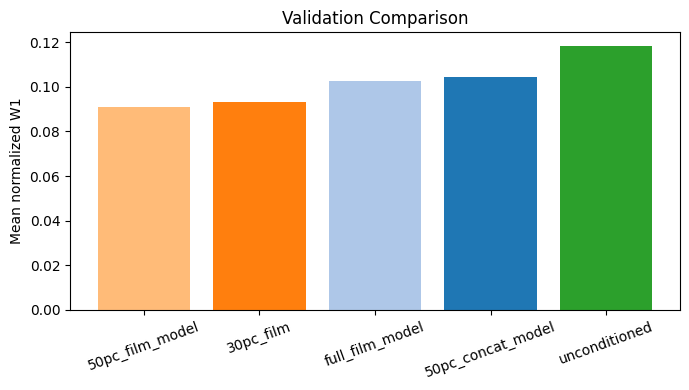

Saved /Users/hannesneumann/Repositories/conditional-flow-matching-seminar/outputs/validation_model_comparison/validation_model_summary.png


model,30pc_film,50pc_concat_model,50pc_film_model,full_film_model,unconditioned
feature,,,,,
MedianRadius,0.257628,0.265340,0.267761,0.280034,0.264892
HuMoment_5,0.196754,0.097182,0.217498,0.197446,0.097726
HuMoment_3,0.134960,0.084163,0.147052,0.167525,0.096776
NormalizedMoment_2_2,0.131530,0.097194,0.137830,0.129797,0.128150
HuMoment_0,0.131389,0.100220,0.129384,0.129135,0.130036
HuMoment_2,0.129327,0.076559,0.128065,0.133482,0.084886
InertiaTensorEigenvalues_0,0.125516,0.156425,0.112665,0.143340,0.187583
HuMoment_4,0.123065,0.086388,0.177806,0.164484,0.091203
MajorAxisLength,0.122795,0.158600,0.101944,0.131791,0.184658


In [9]:
if not summary_df.empty:
    summary_df_sorted = summary_df.sort_values("mean_normalized_w1")
    colors = plt.cm.tab20(np.random.permutation(len(summary_df)))
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(summary_df_sorted["model"], summary_df_sorted["mean_normalized_w1"].sort_values(), color=colors)
    ax.set_ylabel("Mean normalized W1")
    ax.set_title("Validation Comparison")
    ax.tick_params(axis="x", rotation=20)
    plt.tight_layout()
    path = Path(cfg.output_dir) / "validation_model_summary.png"
    plt.savefig(path, dpi=140)
    plt.show()
    print(f"Saved {path}")

if not feature_df.empty:
    pivot = feature_df.pivot(index="feature", columns="model", values="normalized_w1")
    display(pivot.sort_values(pivot.columns[0], ascending=False).head(15))

In [11]:
FEATURE_GROUPS = {
    "Size": [
        "Area", "BoundingBoxArea", "ConvexArea", "EquivalentDiameter",
        "Perimeter", "PerimeterCrofton", "MajorAxisLength", "MinorAxisLength",
        "MaximumRadius", "MeanRadius", "MedianRadius", "FilledArea",
    ],
    "Shape": [
        "Eccentricity", "FormFactor", "Extent", "Solidity", "Compactness",
        "EulerNumber",
    ],
    "Central Moments": [
        "CentralMoment_0_0", "CentralMoment_0_1", "CentralMoment_0_2",
        "CentralMoment_0_3", "CentralMoment_1_0", "CentralMoment_1_1",
        "CentralMoment_1_2", "CentralMoment_1_3", "CentralMoment_2_0",
        "CentralMoment_2_1", "CentralMoment_2_2", "CentralMoment_2_3",
    ],
    "Normalized Moments": [
        "NormalizedMoment_0_2", "NormalizedMoment_0_3",
        "NormalizedMoment_1_1", "NormalizedMoment_1_2",
        "NormalizedMoment_1_3", "NormalizedMoment_2_0",
        "NormalizedMoment_2_1", "NormalizedMoment_2_2",
        "NormalizedMoment_2_3", "NormalizedMoment_3_0",
        "NormalizedMoment_3_1", "NormalizedMoment_3_2",
        "NormalizedMoment_3_3",
    ],
    "Hu Moments": [
        "HuMoment_0", "HuMoment_1", "HuMoment_2", "HuMoment_3",
        "HuMoment_4", "HuMoment_5", "HuMoment_6",
    ],
    "Inertia": [
        "InertiaTensor_0_0", "InertiaTensor_0_1",
        "InertiaTensor_1_0", "InertiaTensor_1_1",
        "InertiaTensorEigenvalues_0", "InertiaTensorEigenvalues_1",
    ],
}


In [12]:
# Compare models by morphological feature groups

feature_to_group = {
    feature: group
    for group, features in FEATURE_GROUPS.items()
    for feature in features
}

grouped_feature_df = feature_df.copy()
grouped_feature_df["feature_group"] = grouped_feature_df["feature"].map(feature_to_group)
grouped_feature_df["feature_group"] = grouped_feature_df["feature_group"].fillna("Other")

group_summary = (
    grouped_feature_df
    .groupby(["model", "feature_group"], as_index=False)
    .agg(
        n_features=("feature", "nunique"),
        mean_w1=("w1", "mean"),
        median_w1=("w1", "median"),
        mean_normalized_w1=("normalized_w1", "mean"),
        median_normalized_w1=("normalized_w1", "median"),
    )
    .sort_values(["feature_group", "mean_normalized_w1"])
)

display(group_summary)

,model,feature_group,n_features,mean_w1,median_w1,mean_normalized_w1,median_normalized_w1
12,50pc_film_model,Central Moments,12,495.983868,41.725892,0.056656,0.046464
18,full_film_model,Central Moments,12,475.962092,43.945662,0.067288,0.057504
0,30pc_film,Central Moments,12,774.183329,57.303011,0.069194,0.072274
6,50pc_concat_model,Central Moments,12,815.663699,101.158733,0.101507,0.104534
24,unconditioned,Central Moments,12,1016.904808,102.582743,0.112594,0.127409
7,50pc_concat_model,Hu Moments,7,0.000964,0.000055,0.086620,0.086388
25,unconditioned,Hu Moments,7,0.001248,0.000064,0.098185,0.096776
1,30pc_film,Hu Moments,7,0.001230,0.000089,0.128173,0.129327
13,50pc_film_model,Hu Moments,7,0.001204,0.000097,0.139924,0.129384
19,full_film_model,Hu Moments,7,0.001255,0.000110,0.142456,0.133482


In [13]:
group_pivot = group_summary.pivot(
    index="feature_group",
    columns="model",
    values="mean_normalized_w1",
)

display(group_pivot)

model,30pc_film,50pc_concat_model,50pc_film_model,full_film_model,unconditioned
feature_group,,,,,
Central Moments,0.069194,0.101507,0.056656,0.067288,0.112594
Hu Moments,0.128173,0.086620,0.139924,0.142456,0.098185
Inertia,0.094940,0.128081,0.087508,0.105507,0.143737
Normalized Moments,0.089164,0.067042,0.091549,0.096651,0.080584
Shape,0.076611,0.077885,0.087534,0.094319,0.090135
Size,0.109130,0.158488,0.100086,0.123279,0.178832


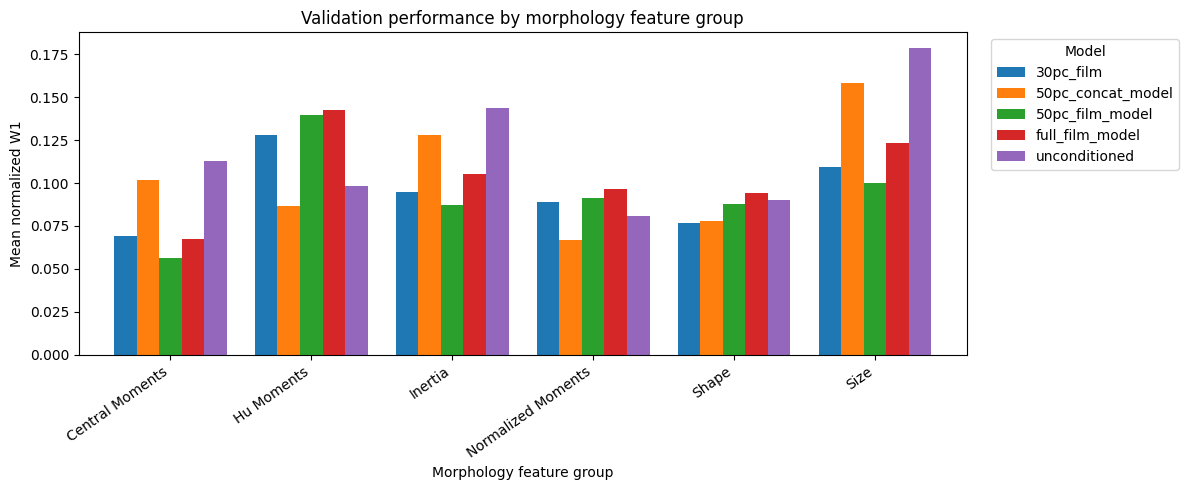

In [14]:
ax = group_pivot.plot(
    kind="bar",
    figsize=(12, 5),
    width=0.8,
)

ax.set_ylabel("Mean normalized W1")
ax.set_xlabel("Morphology feature group")
ax.set_title("Validation performance by morphology feature group")
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

/var/folders/m8/trnx4qbn4c3_95k5_lkbmxwh0000gn/T/ipykernel_23407/1801857190.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(


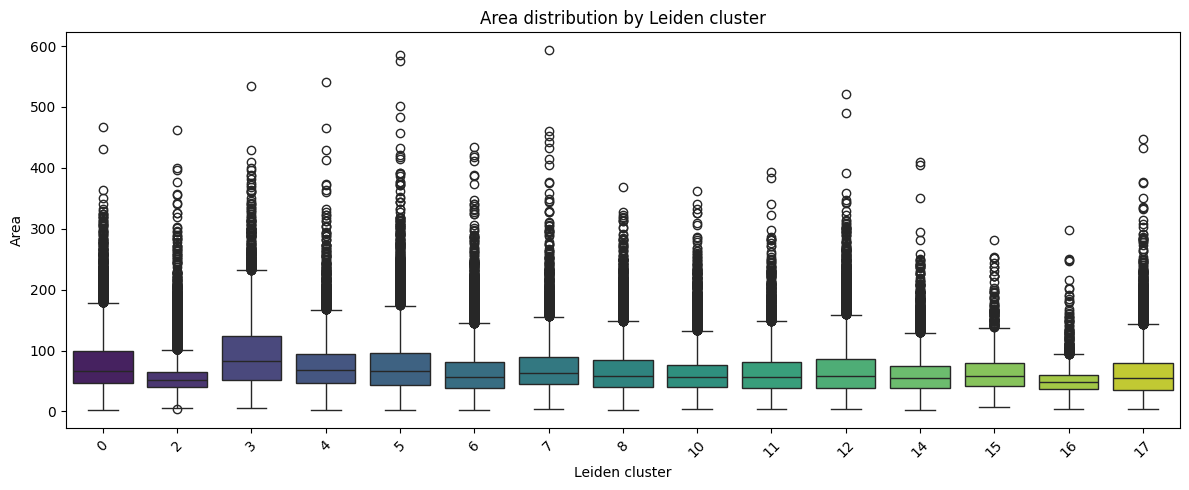

In [15]:
import seaborn as sb
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
sb.boxplot(
    x="leiden",
    y="Area",
    data=adata.obs,
    palette="viridis",
)

plt.xlabel("Leiden cluster")
plt.ylabel("Area")
plt.title("Area distribution by Leiden cluster")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/var/folders/m8/trnx4qbn4c3_95k5_lkbmxwh0000gn/T/ipykernel_23407/2415832874.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(x="leiden", y="Area", data=plot_df, palette="viridis")


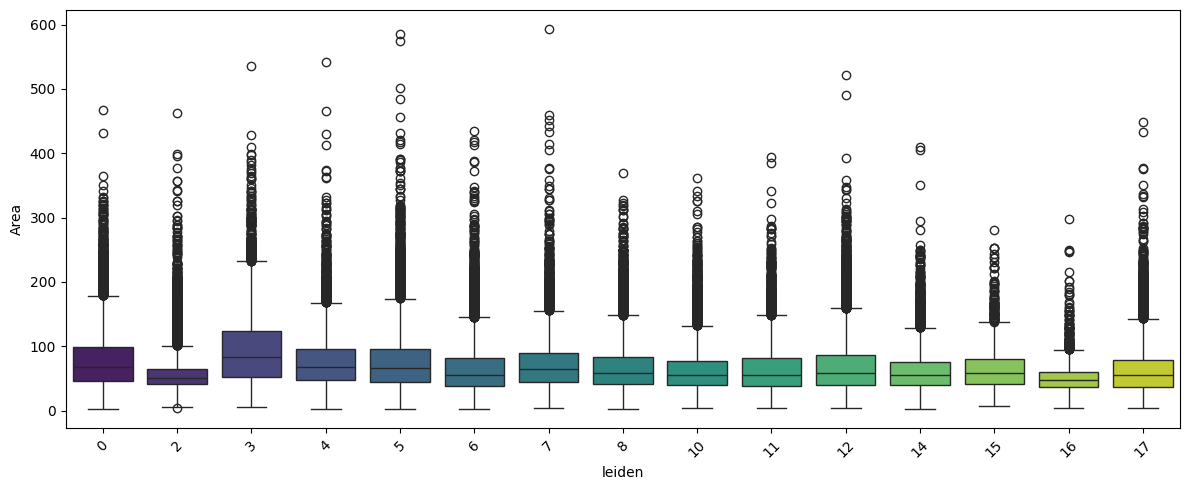

In [16]:
plot_df = adata.obs[["leiden", "Area"]].copy()
plot_df["Area"] = plot_df["Area"].astype(float)

plt.figure(figsize=(12, 5))
sb.boxplot(x="leiden", y="Area", data=plot_df, palette="viridis")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


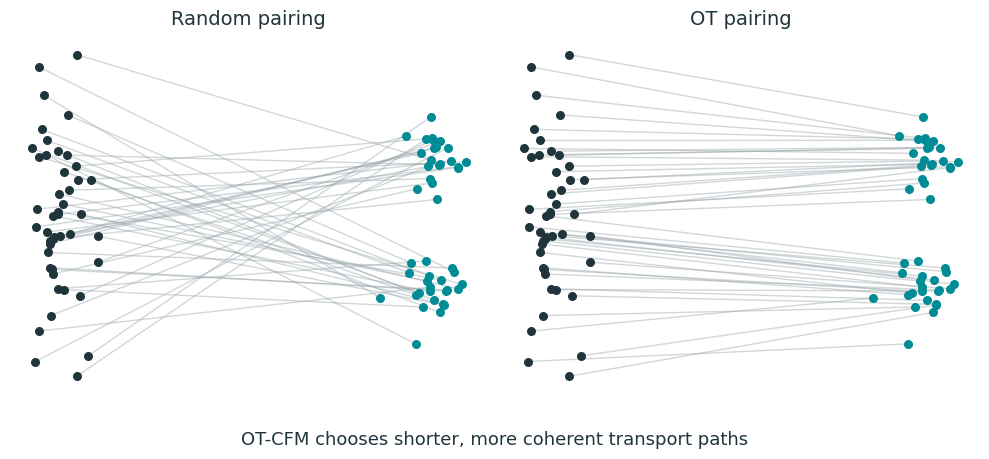

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment

rng = np.random.default_rng(4)

TEAL = "#008C95"
DARK = "#20343C"
GRAY = "#9AA6AC"

N = 45

# Source distribution
x0 = rng.normal(loc=[-2.2, 0.0], scale=[0.20, 0.85], size=(N, 2))

# Target distribution with two clusters
cluster = np.r_[np.zeros(N // 2), np.ones(N - N // 2)].astype(int)
centers = np.array([[2.2, 0.75], [2.2, -0.75]])
x1 = centers[cluster] + rng.normal(scale=[0.20, 0.25], size=(N, 2))
rng.shuffle(x1)

# Random pairing
random_idx = rng.permutation(N)
x1_random = x1[random_idx]

# OT pairing via minimum-cost bipartite matching
cost = ((x0[:, None, :] - x1[None, :, :]) ** 2).sum(axis=2)
row_idx, col_idx = linear_sum_assignment(cost)

x0_ot = x0[row_idx]
x1_ot = x1[col_idx]


def draw_pairing(ax, source, target, title):
    for a, b in zip(source, target):
        ax.plot([a[0], b[0]], [a[1], b[1]], color=GRAY, lw=1.0, alpha=0.45)

    ax.scatter(source[:, 0], source[:, 1], s=30, color=DARK, zorder=3)
    ax.scatter(target[:, 0], target[:, 1], s=30, color=TEAL, zorder=3)

    ax.set_title(title, fontsize=14, color=DARK, pad=10)
    ax.set_aspect("equal")
    ax.axis("off")


fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

draw_pairing(axes[0], x0, x1_random, "Random pairing")
draw_pairing(axes[1], x0_ot, x1_ot, "OT pairing")

fig.text(
    0.5, 0.03,
    "OT-CFM chooses shorter, more coherent transport paths",
    ha="center",
    fontsize=13,
    color=DARK,
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig("ot_cfm_pairing_visual.svg", bbox_inches="tight", transparent=True)
plt.savefig("ot_cfm_pairing_visual.png", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

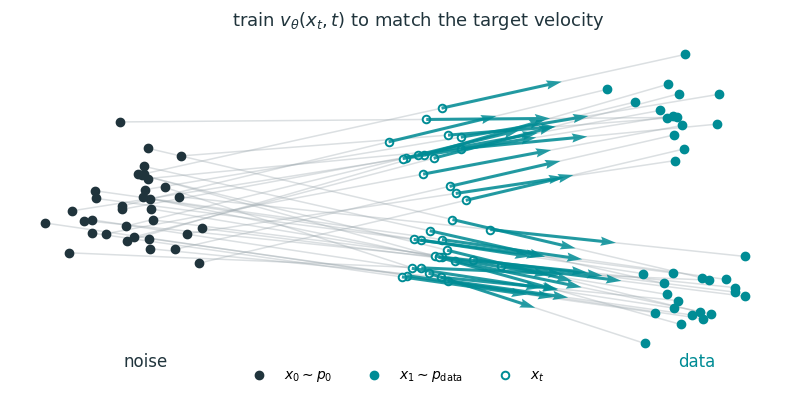

In [25]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)

# Slide-friendly colors
TEAL = "#008C95"
DARK = "#20343C"
GRAY = "#9AA6AC"

N = 35

# Source distribution: simple noise
x0 = rng.normal(loc=[-2.4, 0.0], scale=[0.35, 0.35], size=(N, 2))

# Target distribution: toy "data" with two clusters
cluster = rng.integers(0, 2, size=N)
centers = np.array([[2.3, 0.8], [2.5, -0.8]])
x1 = centers[cluster] + rng.normal(scale=[0.30, 0.22], size=(N, 2))

# Conditional Flow Matching interpolation
t = 0.55
xt = (1 - t) * x0 + t * x1
u = x1 - x0  # target velocity for linear paths

fig, ax = plt.subplots(figsize=(8, 4.5))

# Transport paths
for a, b in zip(x0, x1):
    ax.plot([a[0], b[0]], [a[1], b[1]], color=GRAY, lw=1.1, alpha=0.35)

# Points
ax.scatter(x0[:, 0], x0[:, 1], s=36, color=DARK, label=r"$x_0 \sim p_0$", zorder=3)
ax.scatter(x1[:, 0], x1[:, 1], s=36, color=TEAL, label=r"$x_1 \sim p_{\mathrm{data}}$", zorder=3)
ax.scatter(
    xt[:, 0], xt[:, 1],
    s=30,
    facecolors="white",
    edgecolors=TEAL,
    linewidths=1.4,
    label=r"$x_t$",
    zorder=4,
)

# Velocity arrows at x_t
ax.quiver(
    xt[:, 0], xt[:, 1],
    u[:, 0], u[:, 1],
    angles="xy",
    scale_units="xy",
    scale=4.5,
    width=0.004,
    color=TEAL,
    alpha=0.85,
    zorder=5,
)

ax.text(-2.4, -1.45, "noise", ha="center", color=DARK, fontsize=12)
ax.text(2.45, -1.45, "data", ha="center", color=TEAL, fontsize=12)
ax.text(
    0.0, 1.55,
    r"train $v_\theta(x_t, t)$ to match the target velocity",
    ha="center",
    color=DARK,
    fontsize=13,
)

ax.set_aspect("equal")
ax.axis("off")
ax.legend(
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, -0.12),
)

plt.tight_layout()
plt.savefig("cfm_transport_visual.svg", bbox_inches="tight", transparent=True)
plt.savefig("cfm_transport_visual.png", dpi=300, bbox_inches="tight", transparent=True)
plt.show()